In [ ]:
from dsa.ms_dsa.Evaluation.binding_interface_eval import BIEvaluation
from dsa.ms_dsa.config import ms_data_relativePath
import warnings
#warnings.filterwarnings("ignore")
binding_interface_eval = BIEvaluation(ms_data_relativePath=ms_data_relativePath, 
                                        distance_cutoff=6.5, 
                                        contact_filter_key="lysine_only",
                                        max_uniprot_ids=10)

binding_interface_eval.save_ms_dsa()
# #binding_interface_eval.plot_boxplot()
# for run_index in binding_interface_eval.ms_dsa:
#     binding_interface_eval.plot_dsa_vs_sasa_with_binding_annotation(sasa_type="asa_nz", run_index=run_index)

In [ ]:
from dsa.ms_dsa.Evaluation.binding_interface_eval import BIEvaluation
from dsa.ms_dsa.config import ms_data_relativePath
import warnings
#warnings.filterwarnings("ignore")
binding_interface_eval = BIEvaluation(ms_data_relativePath=ms_data_relativePath, 
                                        distance_cutoff=6.5, 
                                        contact_filter_key="lysine_only",
                                        max_uniprot_ids=10)

binding_interface_eval.save_ms_dsa()
# #binding_interface_eval.plot_boxplot()
# for run_index in binding_interface_eval.ms_dsa:
#     binding_interface_eval.plot_dsa_vs_sasa_with_binding_annotation(sasa_type="asa_nz", run_index=run_index)

In [2]:
from dsa.ms_dsa.Evaluation.binding_interface_eval import BIEvaluation
ms_dsa_by_run = {}
import pandas as pd
for run_index in range(5):
    #ms_dsa_by_run[run_index] = BIEvaluation.load_processed_ms_dsa(run_index)
    ms_dsa_by_run[run_index] = pd.read_csv(f"/home/shajain/DynamicSurfaceAccessibility/ms_dsa_with_binding_interface_and_sasa_scores_{run_index}.csv")


In [6]:
ms_dsa_by_run[0]

,peptide_seq,Run,Run.Index,MS_DSA,Protein.Names,Genes,Protein.Ids,Protein.Group,multiple_entries,Uniprot,...,salt_bridge_alphafold,hydrogen_bond_pdb,hydrogen_bond_alphafold,cation_pi_pdb,cation_pi_alphafold,covalent_isopeptide_pdb,covalent_isopeptide_alphafold,asa_nz_avg,asa_nz_min,asa_nz_max
0,AAAAVEPDVVVKR,2025-12-02_SS_CPP_qcmethod_30nce,0,1.0,SELS_HUMAN,SELENOS,Q9BQE4,Q9BQE4,False,Q9BQE4,...,False,False,False,False,False,False,False,NaN,NaN,NaN
1,AAAGGQGSAVAAEAEPGKEEPPAR,2025-12-02_SS_CPP_qcmethod_30nce,0,1.0,EGLN1_HUMAN,EGLN1,Q9GZT9,Q9GZT9,False,Q9GZT9,...,False,False,False,False,False,False,False,57.2050,57.205,57.205
2,AAAGLLPGGKAR,2025-12-02_SS_CPP_qcmethod_30nce,0,1.0,STRP1_HUMAN,STRIP1,Q5VSL9,Q5VSL9,False,Q5VSL9,...,False,False,False,False,False,False,False,57.2310,57.231,57.231
3,AAAMDVDTPSGTNSGAGKKR,2025-12-02_SS_CPP_qcmethod_30nce,0,NaN,RBX1_HUMAN,RBX1,P62877,P62877,False,P62877,...,False,True,False,True,False,True,False,57.6060,57.305,57.907
4,AAAMGEKKEGGGGGDAAAAEGGAGAAASR,2025-12-02_SS_CPP_qcmethod_30nce,0,1.0,KSR1_HUMAN,KSR1,Q8IVT5,Q8IVT5,False,Q8IVT5,...,False,False,False,False,False,False,False,57.8060,57.785,57.827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11937,YYSLPPHQKVPLPSLSPTMQAGTIAR,2025-12-02_SS_CPP_qcmethod_30nce,0,1.0,ODP2_HUMAN,DLAT,P10515,P10515,False,P10515,...,False,False,False,False,False,False,False,37.5860,37.586,37.586
11938,YYSSENTRPKFLSR,2025-12-02_SS_CPP_qcmethod_30nce,0,1.0,SMC6_HUMAN,SMC6,Q96SB8,Q96SB8,False,Q96SB8,...,True,False,True,False,False,False,False,38.5740,38.574,38.574
11939,YYSYGLEKKFR,2025-12-02_SS_CPP_qcmethod_30nce,0,1.0,LARP1_HUMAN,LARP1,Q6PKG0,Q6PKG0,False,Q6PKG0,...,True,True,True,False,False,False,False,26.9385,25.442,28.435
11940,YYTEFPTVLDITAEDPSKSYVKLR,2025-12-02_SS_CPP_qcmethod_30nce,0,1.0,HAT1_HUMAN,HAT1,O14929,O14929,False,O14929,...,True,False,True,False,False,False,False,27.3085,22.389,32.228


In [49]:

import matplotlib.pyplot as plt
import numpy as np

def _mask(ms_dsa, contact_type, source="pdb", bond_type='salt_bridge', strict=False):
    contact_col = {
        ("inter_chain", "pdb"): "inter_chain_pdb",
        ("intra_chain", "pdb"): "intra_chain_pdb",
        ("intra_chain", "alphafold"): "intra_chain_alphafold",
    }[(contact_type, source)]
    m = ms_dsa[contact_col].fillna(False).astype(bool)
    if strict and contact_type == "inter_chain":
        m = m & ~ms_dsa["intra_chain_pdb"].fillna(False).astype(bool)
    if bond_type is not None:
        m = m & ms_dsa[f"{bond_type}_{source}"].fillna(False).astype(bool)
    return m

def _frac_lt(df, thresh=0.9):
    if len(df) == 0:
        return np.nan
    return (df["MS_DSA"] < thresh).mean()


# def boxplot(ms_dsa, source="pdb", bond_type=None, strict=False, col="MS_DSA", run_index=None):
#     ms_dsa = ms_dsa[ms_dsa["skipped"] == False]
#     inter = ms_dsa[_mask(ms_dsa, "inter_chain", source, bond_type, strict)]
#     intra = ms_dsa[_mask(ms_dsa, "intra_chain", "alphafold", bond_type)]
#     not_contact = ms_dsa[
#         ~_mask(ms_dsa, "inter_chain", "pdb")
#         & ~_mask(ms_dsa, "intra_chain", "pdb")
#         & ~_mask(ms_dsa, "intra_chain", "alphafold")
#     ]
#     print(f"Inter: {inter.shape}  Intra: {intra.shape}  Not contact: {not_contact.shape}")
#     plt.boxplot(inter[col].dropna().values, label="Inter")
#     plt.boxplot(intra[col].dropna().values, label="Intra AF")
#     plt.boxplot(not_contact[col].dropna().values, label="Not Contact")
#     plt.xlabel("MS_DSA")
#     plt.ylabel("Frequency")
#     plt.title(f"MS_DSA Distribution on Run {run_index}")
#     plt.legend()
#     plt.show()

def histograms(ms_dsa, source="pdb", bond_type=None, strict=False, col="MS_DSA", run_index=None):
    ms_dsa = ms_dsa[ms_dsa["skipped"] == False]
    inter = ms_dsa[_mask(ms_dsa, "inter_chain", source, bond_type, strict)]
    intra = ms_dsa[_mask(ms_dsa, "intra_chain", "alphafold", bond_type)]
    not_contact = ms_dsa[
        ~_mask(ms_dsa, "inter_chain", "pdb")
        & ~_mask(ms_dsa, "intra_chain", "pdb")
        & ~_mask(ms_dsa, "intra_chain", "alphafold")
    ]
    print(f"Inter: {inter.shape}  Intra: {intra.shape}  Not contact: {not_contact.shape}")
    
    plt.hist(inter[col].dropna().values, bins=10, label="Inter", alpha=0.25, density=True)
    plt.hist(intra[col].dropna().values, bins=10, label="Intra AF", alpha=0.25, density=True)
    plt.hist(not_contact[col].dropna().values, bins=10, label="Not Contact", alpha=0.25, density=True)
    plt.xlabel("MS_DSA")
    plt.ylabel("Frequency")
    plt.title(f"MS_DSA Distribution on Run {run_index}")
    plt.legend()
    plt.show()

def plot_dsa_vs_sasa_with_binding_annotation(
    ms_dsa,
    contact_type="inter_chain",
    bond_type=None,
    source="pdb",
    sasa_type="asa_nz",
    statistic="max",
    strict=False,
    run_index=None,
):
    ms_dsa = ms_dsa[ms_dsa["skipped"] == False]
    sasa_column = f"{sasa_type}_{statistic}"

    inter = ms_dsa[_mask(ms_dsa, "inter_chain", "pdb", bond_type, strict)]
    intra = ms_dsa[_mask(ms_dsa, "intra_chain", "alphafold", bond_type)]
    intra_pdb = ms_dsa[_mask(ms_dsa, "intra_chain", "pdb", bond_type)]
    not_contact = ms_dsa[
        ~_mask(ms_dsa, "inter_chain", "pdb")
        & ~_mask(ms_dsa, "intra_chain", "pdb")
        & ~_mask(ms_dsa, "intra_chain", "alphafold")
    ]

    highlight = ms_dsa[_mask(ms_dsa, contact_type, source, bond_type, strict)]

    print(f"Inter PDB: {inter.shape}  ({_frac_lt(inter):.3f} < 0.9)")
    print(f"Intra PDB: {intra_pdb.shape}  ({_frac_lt(intra_pdb):.3f} < 0.9)")
    print(f"Intra AF: {intra.shape}  ({_frac_lt(intra):.3f} < 0.9)")
    print(f"Not contact: {not_contact.shape}  ({_frac_lt(not_contact):.3f} < 0.9)")
    plt.scatter(not_contact["MS_DSA"].values, not_contact[sasa_column].values, color="grey", label="Not Contact", s=20, alpha=0.5)
    plt.scatter(intra["MS_DSA"].values, intra[sasa_column].values, color="green", label="Intra AF", s=10, alpha=0.5)
    plt.scatter(highlight["MS_DSA"].values, highlight[sasa_column].values, color="red", label=f"{contact_type}/{source}", s=5, alpha=0.5)
    plt.xlabel("MS_DSA")
    plt.ylabel(sasa_column)
    plt.title(f"MS_DSA vs {sasa_column} on Run {run_index}")
    plt.legend()
    plt.show()

In [41]:
import numpy as np
import matplotlib.pyplot as plt

def histograms_equal_width(
    ms_dsa,
    source="pdb",
    bond_type=None,
    strict=False,
    col="MS_DSA",
    run_index=None,
):
    ms_dsa = ms_dsa[ms_dsa["skipped"] == False]
    inter = ms_dsa[_mask(ms_dsa, "inter_chain", source, bond_type, strict)]
    intra = ms_dsa[_mask(ms_dsa, "intra_chain", "alphafold", bond_type)]
    intra_pdb = ms_dsa[_mask(ms_dsa, "intra_chain", "pdb", bond_type)]
    not_contact = ms_dsa[
        ~_mask(ms_dsa, "inter_chain", "pdb", bond_type, strict)
        & ~_mask(ms_dsa, "intra_chain", "pdb", bond_type)
        & ~_mask(ms_dsa, "intra_chain", "alphafold", bond_type)
    ]
    inter_count = len(inter)
    intra_count = len(intra)
    not_contact_count = len(not_contact)
    if col == "MS_DSA":
        bins = np.array([0.0, 0.1, 0.9, 1.0])
        labels = ["0–0.1", "0.1–0.9", "0.9–1.0"]
    elif col == "asa_nz_max":
        bins = np.array([0.0, 20.0, 40.0, 60.0])
        labels = ["0–20", "20–40", "40–60"]
    groups = [
        ("Inter", inter[col].dropna().values, inter_count, "tab:red"),
        ("Intra AF", intra[col].dropna().values, intra_count, "tab:green"),
        #("Intra PDB", intra_pdb[col].dropna().values, "tab:blue"),
        ("Not Contact", not_contact[col].dropna().values, not_contact_count, "grey"),
    ]
    x = np.arange(len(labels))
    width = 0.25
    fig, ax = plt.subplots()
    for i, (name, values, count, color) in enumerate(groups):
        # density, _ = np.histogram(values, bins=bins, density=True)
        # ax.bar(x + (i - 1) * width, density, width, label=name, color=color, alpha=0.7)
        counts, _ = np.histogram(values, bins=bins)
        pct = 100.0 * counts / counts.sum()   # three numbers, sum to 100
        ax.bar(x + (i - 1) * width, pct, width, label=f"{name} ({count})", color=color, alpha=0.7)
    ax.set_ylabel("Percent of peptides")
    ax.set_xticks(x, labels)
    # ax.set_ylabel("Density")
    ax.set_xlabel(col)
    ax.set_title(f"{col} Binned peptides on Run {run_index}")
    ax.legend()
    #plt.yscale("log")
    plt.show()

Inter PDB: (1275, 27)  (0.046 < 0.9)
Intra PDB: (3087, 27)  (0.060 < 0.9)
Intra AF: (3944, 27)  (0.064 < 0.9)
Not contact: (6478, 27)  (0.084 < 0.9)


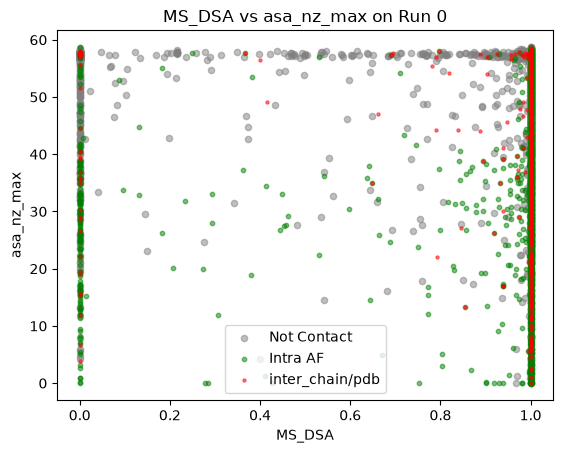

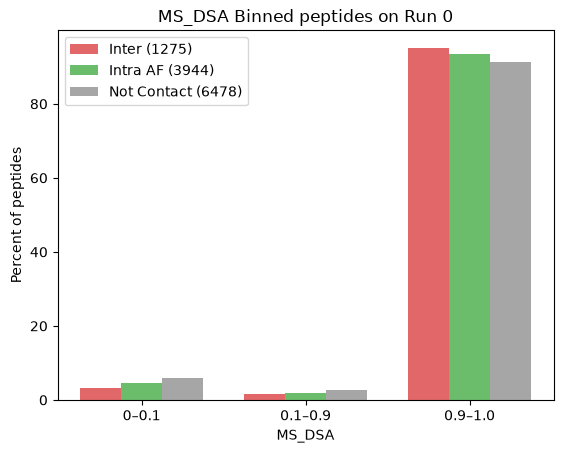

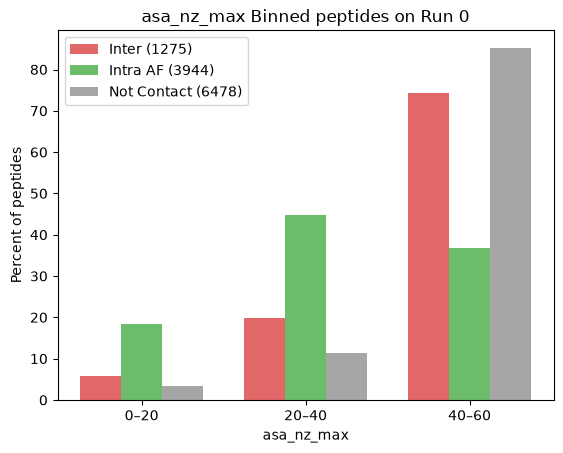

Inter PDB: (1060, 27)  (0.047 < 0.9)
Intra PDB: (2672, 27)  (0.067 < 0.9)
Intra AF: (3389, 27)  (0.079 < 0.9)
Not contact: (5640, 27)  (0.090 < 0.9)


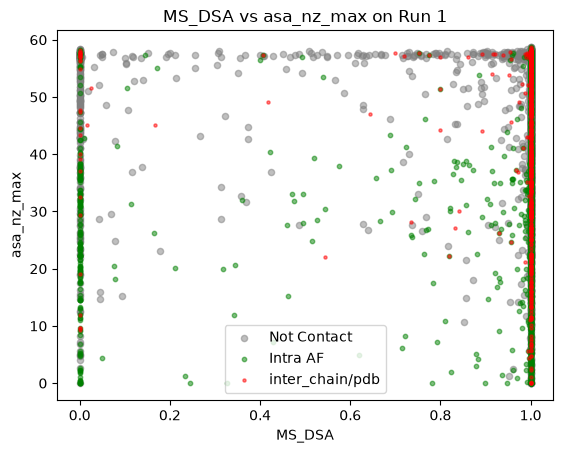

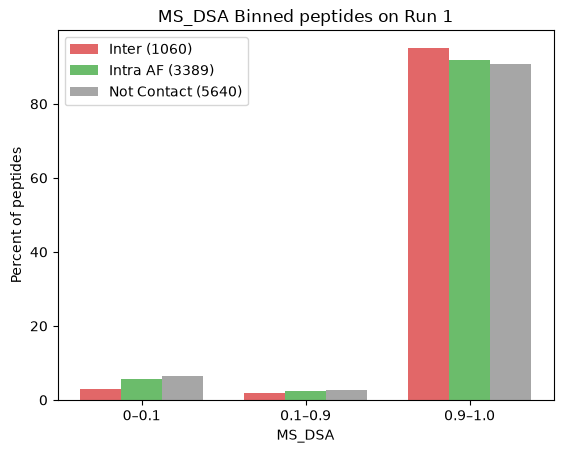

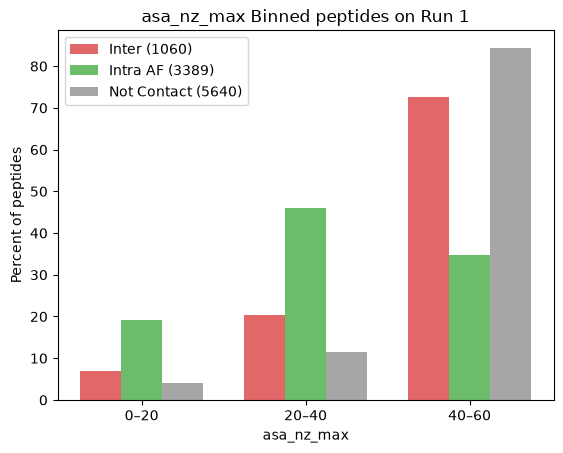

Inter PDB: (1304, 27)  (0.044 < 0.9)
Intra PDB: (3279, 27)  (0.059 < 0.9)
Intra AF: (4183, 27)  (0.061 < 0.9)
Not contact: (6673, 27)  (0.079 < 0.9)


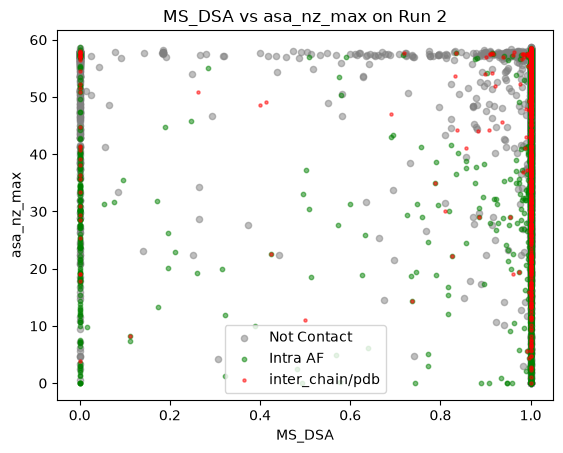

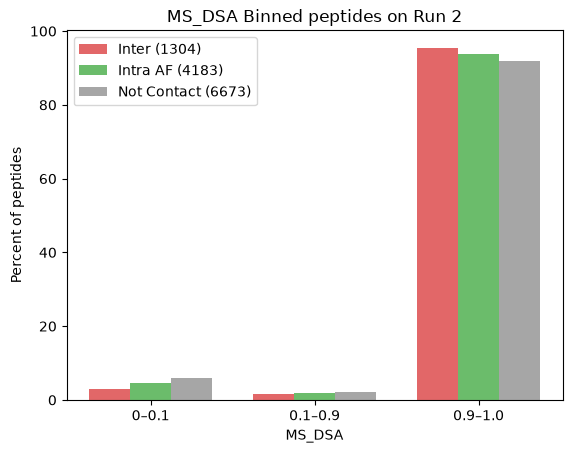

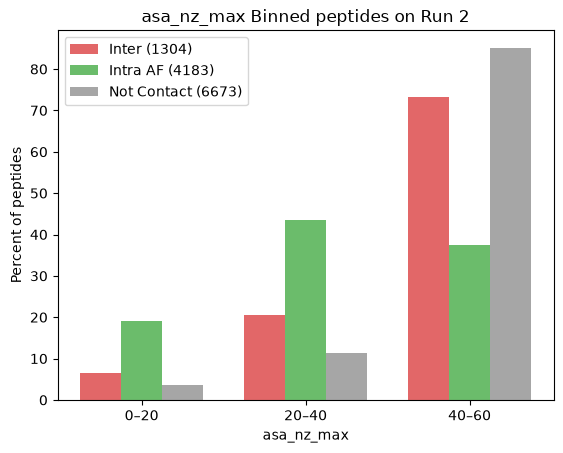

Inter PDB: (1255, 27)  (0.066 < 0.9)
Intra PDB: (3143, 27)  (0.075 < 0.9)
Intra AF: (4052, 27)  (0.074 < 0.9)
Not contact: (6536, 27)  (0.091 < 0.9)


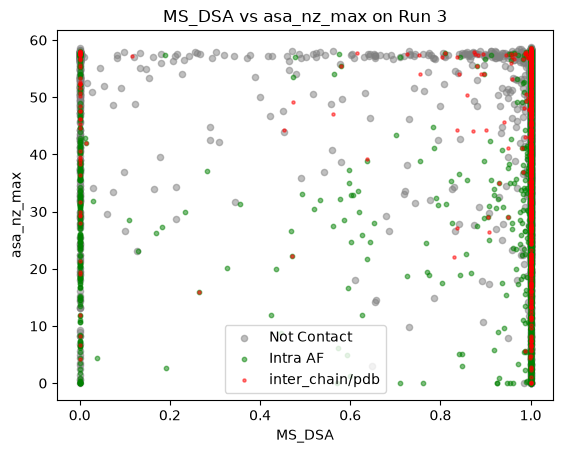

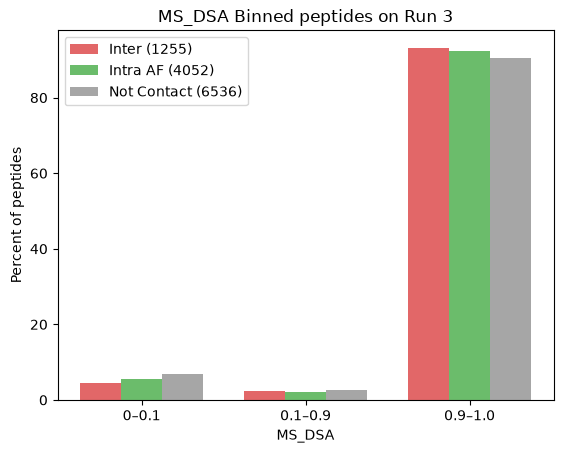

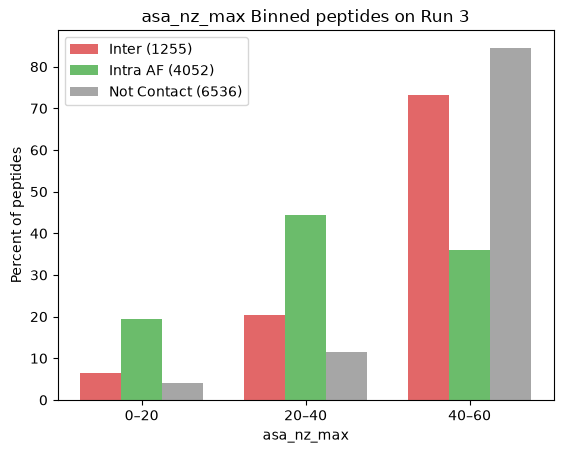

Inter PDB: (1183, 27)  (0.041 < 0.9)
Intra PDB: (2992, 27)  (0.061 < 0.9)
Intra AF: (3821, 27)  (0.065 < 0.9)
Not contact: (6219, 27)  (0.079 < 0.9)


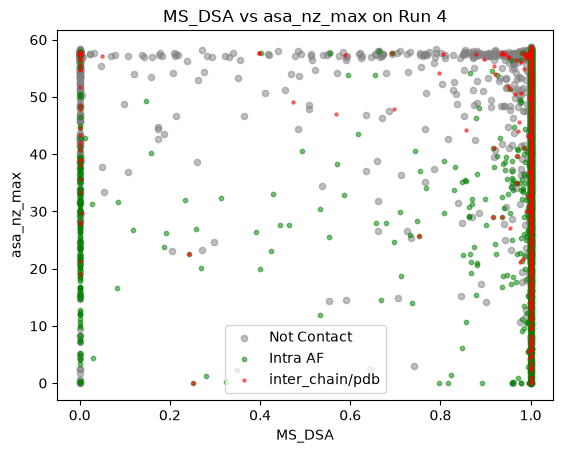

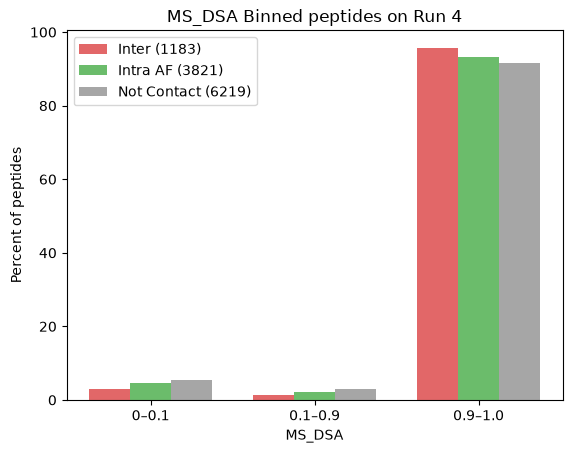

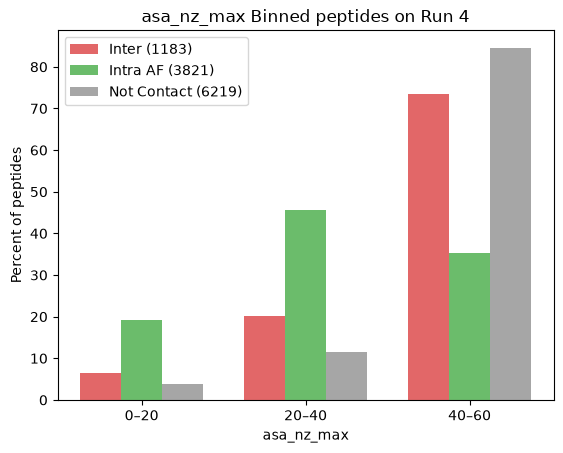

In [50]:
from dsa.ms_dsa.Evaluation.binding_interface_eval import BIEvaluation
ms_dsa_by_run = {}
import pandas as pd
strict = False
for run_index in range(5):
    #ms_dsa_by_run[run_index] = BIEvaluation.load_processed_ms_dsa(run_index)
    ms_dsa_by_run[run_index] = pd.read_csv(f"/home/shajain/DynamicSurfaceAccessibility/ms_dsa_with_binding_interface_and_sasa_scores_{run_index}.csv")
    plot_dsa_vs_sasa_with_binding_annotation(ms_dsa_by_run[run_index], bond_type='salt_bridge', run_index=run_index, strict=strict)
    # histograms(ms_dsa_by_run[run_index], bond_type='salt_bridge', run_index=run_index)
    histograms_equal_width(ms_dsa_by_run[run_index], bond_type='salt_bridge', col="MS_DSA", run_index=run_index, strict=strict)
    histograms_equal_width(ms_dsa_by_run[run_index], bond_type='salt_bridge', col="asa_nz_max", run_index=run_index, strict=strict)